In [1]:
!pip install gymnasium


   ---------------------------------------- 0.0/953.9 kB ? eta -:--:--
   --------------------------------------- 953.9/953.9 kB 10.4 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   ---------------------------------------- 2/2 [gymnasium]



In [2]:
!pip install "gymnasium[toy-text]"

   ---------------------------------------- 0.0/10.4 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/10.4 MB 15.4 MB/s eta 0:00:01
   -------- ------------------------------- 2.1/10.4 MB 4.9 MB/s eta 0:00:02
   -------- ------------------------------- 2.1/10.4 MB 4.9 MB/s eta 0:00:02
   -------------- ------------------------- 3.7/10.4 MB 4.2 MB/s eta 0:00:02
   -------------------- ------------------- 5.2/10.4 MB 5.4 MB/s eta 0:00:01
   ------------------------ --------------- 6.3/10.4 MB 4.9 MB/s eta 0:00:01
   ------------------------ --------------- 6.3/10.4 MB 4.9 MB/s eta 0:00:01
   ------------------------------------ --- 9.4/10.4 MB 5.7 MB/s eta 0:00:01
   ------------------------------------ --- 9.4/10.4 MB 5.7 MB/s eta 0:00:01
   ---------------------------------------  10.2/10.4 MB 5.1 MB/s eta 0:00:01
   ---------------------------------------- 10.4/10.4 MB 4.8 MB/s eta 0:00:00


In [2]:
import gymnasium as gym
import numpy as np
import random

In [3]:
print(env.observation_space.n)
print(env.action_space.n)

state , _ = env.reset()
print(state)

NameError: name 'env' is not defined

In [4]:
# 1.alpha = 0.5
# 2. gamma = 0.9
# 3. episodes = 500
# 4.epsilon = 0.1

In [4]:
alpha = 0.5
gamma = 0.9
episodes = 500
epsilon = 0.1

In [5]:
# Q-table => store Q-values

Q = np.zeros((48 , 4))

In [6]:
#Policy - epsilon greedy (states that first we take an action base)

def epsilon_greedy(state):
    if random.random() < epsilon:
        return env.action_space.sample() # random action => EXPLORE
    else:
        return np.argmax(Q[state]) # EXPLOIT

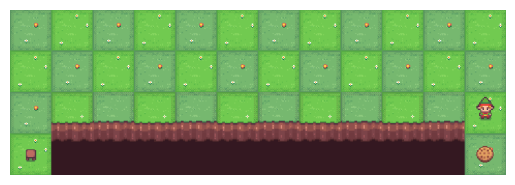

Episode 450: Reward=-17, Length=17
Episode 451: Reward=-18, Length=18
Episode 452: Reward=-117, Length=18
Episode 453: Reward=-19, Length=19
Episode 454: Reward=-22, Length=22
Episode 455: Reward=-17, Length=17
Episode 456: Reward=-23, Length=23
Episode 457: Reward=-19, Length=19
Episode 458: Reward=-31, Length=31
Episode 459: Reward=-21, Length=21
Episode 460: Reward=-27, Length=27
Episode 461: Reward=-21, Length=21
Episode 462: Reward=-24, Length=24
Episode 463: Reward=-27, Length=27
Episode 464: Reward=-19, Length=19
Episode 465: Reward=-24, Length=24
Episode 466: Reward=-18, Length=18
Episode 467: Reward=-29, Length=29
Episode 468: Reward=-24, Length=24
Episode 469: Reward=-35, Length=35
Episode 470: Reward=-123, Length=24
Episode 471: Reward=-19, Length=19
Episode 472: Reward=-23, Length=23
Episode 473: Reward=-20, Length=20
Episode 474: Reward=-29, Length=29
Episode 475: Reward=-28, Length=28
Episode 476: Reward=-34, Length=34
Episode 477: Reward=-29, Length=29
Episode 478: Rewar

In [7]:
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

for episode in range(episodes):

    render = (episode % 50 == 0)

    env = gym.make(
        "CliffWalking-v1",
        render_mode="rgb_array"
    )

    done = False

    state,_ = env.reset()
    action = epsilon_greedy(state)

    total_reward = 0
    episode_len = 0

    while not done:

        # Jupyter animation
        if render:

            clear_output(wait=True)

            frame = env.render()

            plt.imshow(frame)
            plt.axis("off")
            plt.show()

            time.sleep(0.2)

        next_state,reward,terminated,truncated,_ = env.step(action)

        done = terminated or truncated

        next_action = epsilon_greedy(next_state)

        # SARSA update
        Q[state,action] += alpha * (
            reward
            +
            gamma*Q[next_state,next_action]
            -
            Q[state,action]
        )

        state = next_state
        action = next_action

        total_reward += reward
        episode_len += 1

    print(
        f"Episode {episode}: "
        f"Reward={total_reward}, "
        f"Length={episode_len}"
    )

    env.close()

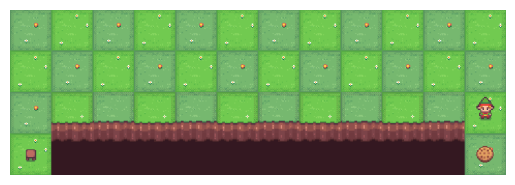

In [9]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

env = gym.make("CliffWalking-v1", render_mode="rgb_array")

state, _ = env.reset()
done = False

while not done:

    clear_output(wait=True)

    frame = env.render()
    plt.imshow(frame)
    plt.axis("off")
    plt.show()

    action = np.argmax(Q[state])

    state, reward, terminated, truncated, _ = env.step(action)

    done = terminated or truncated

    time.sleep(0.3)

env.close()